In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
ENDERECO_DADOS = r'C:/Users/marcelo.mmoreira/Documents/MarceloMM/UC1/codigos_py/Analise/dados_bronze/'
# Ao importar a linha de endereço é necessário inverter as barras para o padrão linux

In [3]:
    # criar um plano de execução sobre o futuro df
    # (depois de rodar uma primeira vez podemos comentar essa linha de código
    # df_bf_exec_plan = pl.scan_parquet(ENDEREÇO_DADOS + 'df_bf.parquet')
try:
    print('Lendo arquivo parquet')

    hora_inicio = dt.datetime.now()
    # cria um plano de execução sobre o futuro df
    df_bf_exec_plan = pl.scan_parquet(
        ENDERECO_DADOS + 'df_bf.parquet'
    )
    df_cidades = pl.scan_csv(ENDERECO_DADOS + '14.CodigosMunic.csv', separator=';')
    
    df_lazy = (
        df_bf_exec_plan.join(
            df_cidades,
            left_on='CÓDIGO MUNICÍPIO SIAFI',
            right_on='COD_SIAFI',
            how='left'
        ).select([pl.col('VALOR PARCELA'),
            pl.col('UF'),
            pl.col('MÊS COMPETÊNCIA'),
            pl.col('NOME')
            ]).with_columns(
                pl.col('MÊS COMPETÊNCIA')
                .cast(pl.Utf8)
                .str.strptime(pl.Date, format='%Y%m')
            )
    )

    hora_fim = dt.datetime.now()

    print(f'Tempo de Execução: {hora_fim - hora_inicio}')

except Exception as e:
    print(f'Erro ao obter dados parquet: {e}')
    
    # fazer o scan com o propósito de ver se a base está sendo visualizada 
    # Vai virar um dataframe quando forem coletadas as colunas
    # df_bf = df_bf_exec_plan.collect()
    # Após a primeira execução também foi transformada em comentário
    # df_bf = pl.read_parquet(ENDEREÇO_DADOS + 'df_bf.parquet')
    hora_fim = dt.datetime.now()
    # print(df_bf.columns)
    # print(df_bf.head())
    # print(f'Tempo de execução: {hora_fim - hora_inicio}')
except Exception as e:
    print(f'Erro ao obter dados parquet: {e}')

Lendo arquivo parquet
Tempo de Execução: 0:00:00.001006


In [4]:
# Análise exploratória básica
coluna_alvo = 'VALOR PARCELA'
df_analises = df_lazy.select(
    pl.col(coluna_alvo).mean().alias('Média'),
    pl.col(coluna_alvo).median().alias('Mediana/Q2'),
    pl.col(coluna_alvo).std().alias('Desvio_padrao'),
    pl.col(coluna_alvo).skew().alias('Assimetria'),
    pl.col(coluna_alvo).kurtosis().alias('Curtose'),
    (pl.col(coluna_alvo).mean() - pl.col(coluna_alvo).median()).alias('Delta_media_mediana'),
    pl.col(coluna_alvo).quantile(0.25).alias('Q1'),
    pl.col(coluna_alvo).quantile(0.75).alias('Q3')
).collect()

In [5]:
try:
    print('preparando dados para visualização')
    df = df_lazy.collect()
    valores = np.array(df['VALOR PARCELA'])
    print(valores)
    q1 = df_analises['Q1'][0]
    q3 = df_analises['Q3'][0]
    iqr = q3 - q1

    lim_sup = q3 + 1.5 * iqr
    lim_inf = q1 - 1.5 * iqr
    outliers_sup = valores > lim_sup
    outliers_inf = valores < lim_inf
    total_outliers = np.sum(outliers_inf) + np.sum(outliers_sup)
    porcentagem_outliers = (total_outliers / len(valores)) * 100
    outliers = outliers_sup | outliers_inf

except Exception as e:
    print(f"Erro na preparação dos dados: {e}")

preparando dados para visualização
[650. 650. 650. ... 600. 600. 650.]


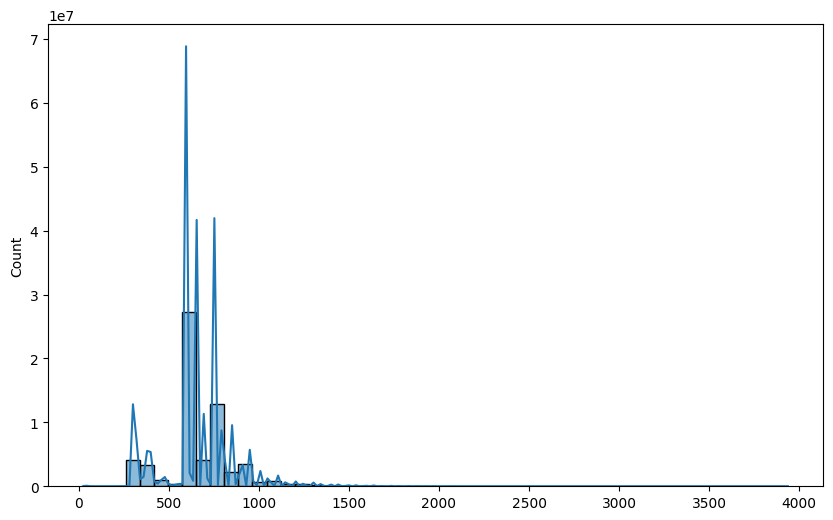

In [ ]:
try:
    plt.figure(figsize=(10, 6))
    sns.histplot(valores, bins=50, kde=True)
    # O seaborn acima cria um histograma com uma linha de densidade
    # kde serve para adicionar a estimativa de densidade do kernel
    # O que é útil para visualizar a distribuição dos dados
    plt.show()
except Exception as e:
    print(f"Erro na visualização de dados: {e}")

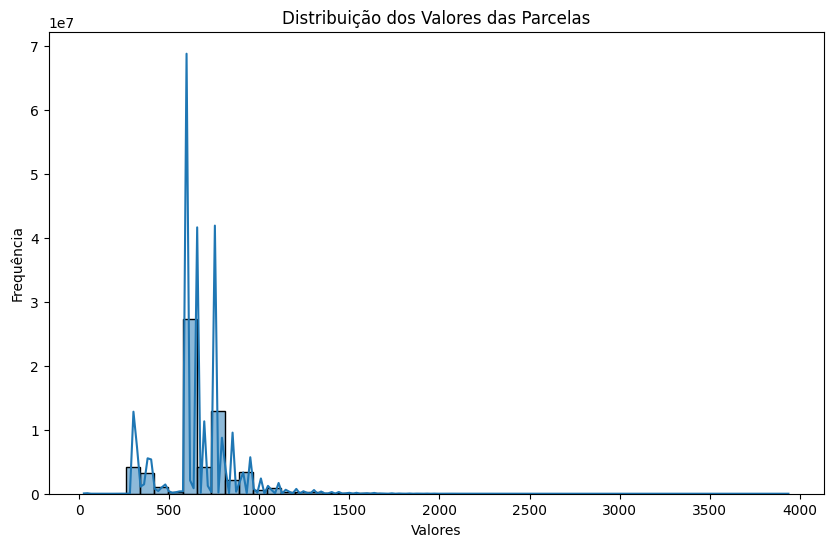

In [7]:
try:
    # histograma smooth
    plt.figure(figsize=(10, 6))
    sns.histplot(valores, bins=50, kde=True)
    plt.title("Distribuição dos Valores das Parcelas")
    plt.xlabel("Valores")
    plt.ylabel("Frequência")
    plt.show()
except Exception as e:
    print(f"Erro na visualização de dados: {e}")

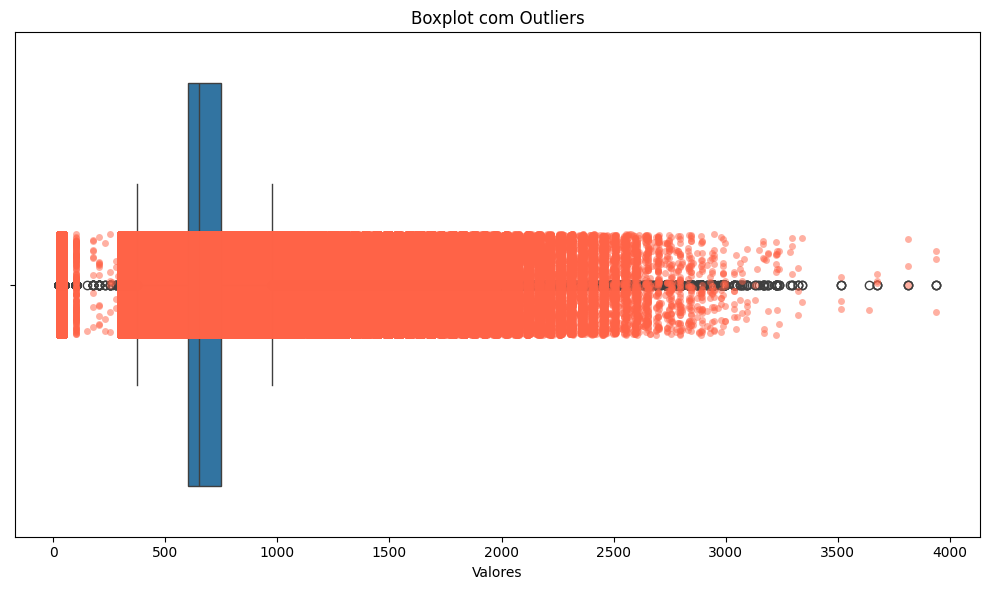

In [8]:
try:
    # Boxplot seaborn
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=valores)
    sns.stripplot(x=valores, color="tomato", alpha=0.5, size=5, jitter=True)
    plt.xlabel("Valores")
    plt.title("Boxplot com Outliers")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro na visualização de Boxplot: {e}")

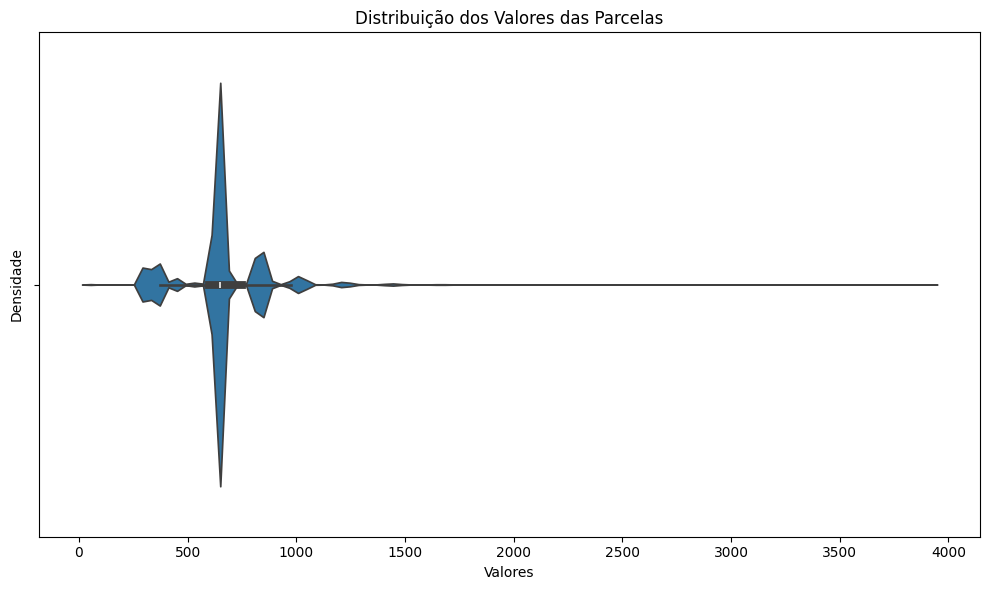

In [ ]:
# Violino
# Esse tipo de gráfico combina características de boxplot e KDE
# Tem como vantagem mostrar a distribuição dos dados de forma mais detalhada
# Ou seja, favorece uma visualização mais completa
# Sua inspiração vem do violino, que possui uma forma semelhante à distribuição dos dados
try:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=valores)
    plt.title("Distribuição dos Valores das Parcelas")
    plt.xlabel("Valores")
    plt.ylabel("Densidade")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro na visualização de Violino: {e}")

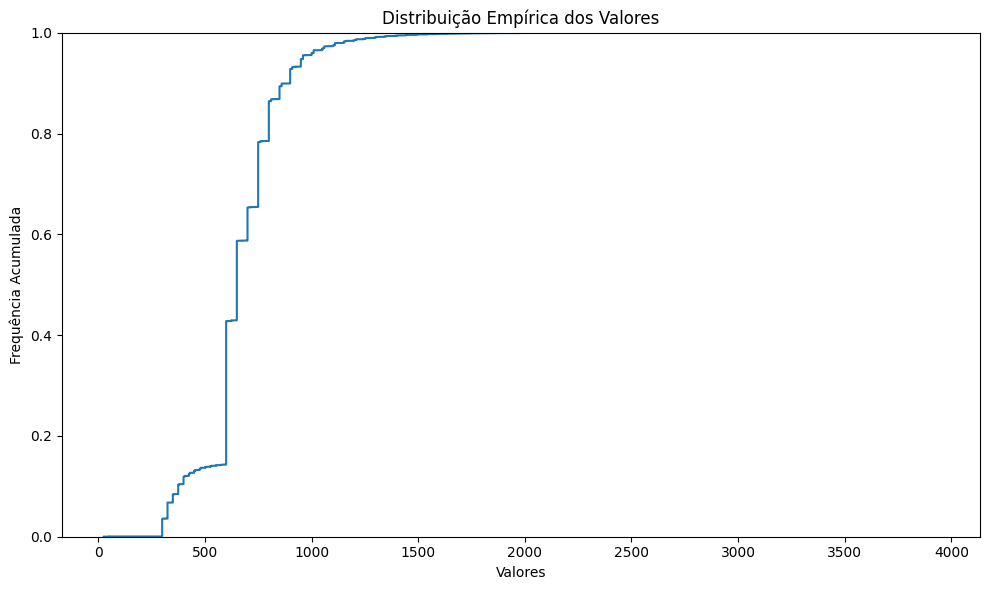

In [10]:
#ECDF
try:
    plt.figure(figsize = (10,6))
    sns.ecdfplot(x=valores)
    plt.title('Distribuição Empírica dos Valores')
    plt.xlabel('Valores')
    plt.ylabel('Frequência Acumulada')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro na visualização de ECDF: {e}")